# Downloading and preprocessing the data

In [1]:
#!/bin/bash
!curl -L -o fake-and-real-news-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/clmentbisaillon/fake-and-real-news-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 40.9M  100 40.9M    0     0  86.7M      0 --:--:-- --:--:-- --:--:-- 86.7M


In [2]:
!unzip /content/fake-and-real-news-dataset.zip

Archive:  /content/fake-and-real-news-dataset.zip
  inflating: Fake.csv                
  inflating: True.csv                


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:

fake_df = pd.read_csv('/content/Fake.csv')
real_df = pd.read_csv('/content/True.csv')

In [5]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
fake_df['label'] = 0
real_df['label'] = 1

In [7]:
full_dataset = pd.concat([fake_df, real_df], ignore_index = True)

In [8]:
print('Fake dataset shape:', fake_df.shape)
print('Real dataset shape:', real_df.shape)
print('Full dataset shape:', full_dataset.shape)

Fake dataset shape: (23481, 5)
Real dataset shape: (21417, 5)
Full dataset shape: (44898, 5)


In [9]:
full_dataset.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [10]:
full_dataset.drop(['subject', 'date', 'title'], axis = 1, inplace = True)

In [11]:
full_dataset.head()

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


In [12]:
df_shuffled = full_dataset.sample(frac=1, random_state=42)

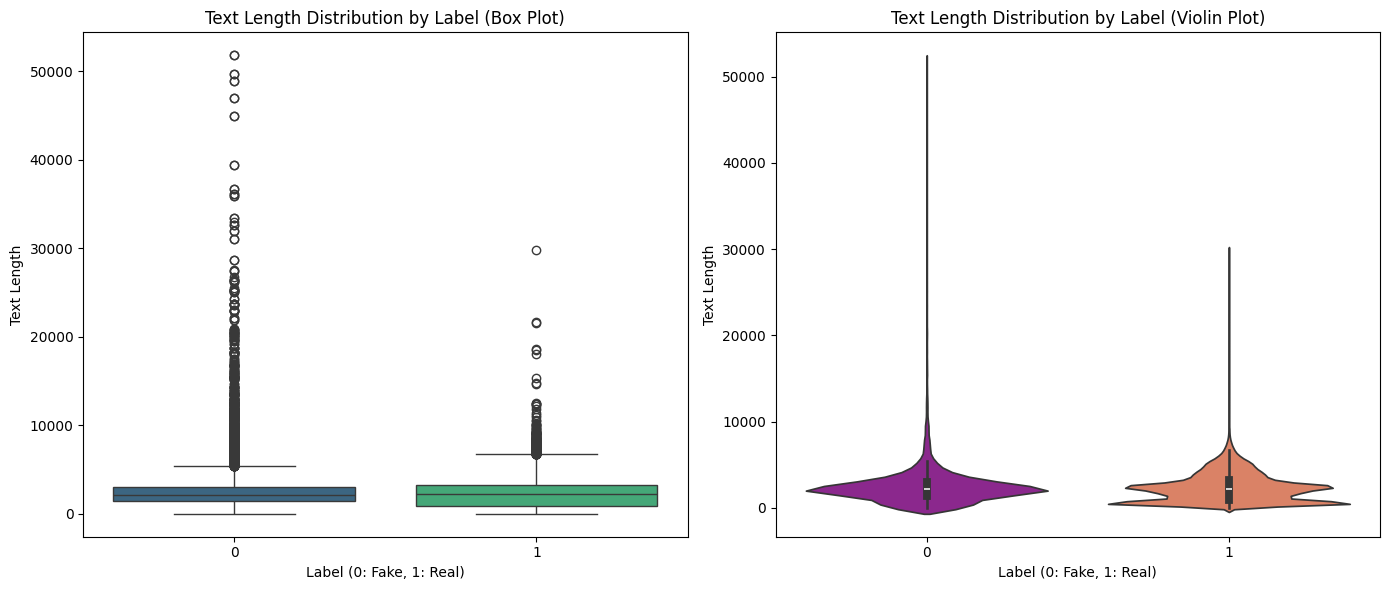

In [16]:
df_shuffled['text_length'] = df_shuffled['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='label', y='text_length', data=df_shuffled, ax=axes[0], palette='viridis', hue='label', legend=False)
axes[0].set_title('Text Length Distribution by Label (Box Plot)')
axes[0].set_xlabel('Label (0: Fake, 1: Real)')
axes[0].set_ylabel('Text Length')

sns.violinplot(x='label', y='text_length', data=df_shuffled, ax=axes[1], palette='plasma', hue='label', legend=False)
axes[1].set_title('Text Length Distribution by Label (Violin Plot)')
axes[1].set_xlabel('Label (0: Fake, 1: Real)')
axes[1].set_ylabel('Text Length')

plt.tight_layout()
plt.show()

In [17]:
train_end = int(0.70 * len(df_shuffled))
val_end = int(0.85 * len(df_shuffled))

train_df = df_shuffled[:train_end]
val_df = df_shuffled[train_end:val_end]
test_df = df_shuffled[val_end:]

In [18]:
print('Train df shape:', train_df.shape)
print('Val df shape:', val_df.shape)
print('Test df shape:', test_df.shape)

Train df shape: (31428, 3)
Val df shape: (6735, 3)
Test df shape: (6735, 3)


# Importing RoBERTa

In [19]:
import torch

from transformers import AutoModelForSequenceClassification, AutoTokenizer


tokenizer = AutoTokenizer.from_pretrained(
    "FacebookAI/roberta-base",
)
model = AutoModelForSequenceClassification.from_pretrained(
    "FacebookAI/roberta-base",
    num_labels=2,
    device_map="auto",
    attn_implementation="sdpa"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

# Fine-tuning the model

In [ ]:
def tokenize_dataset(examples):
  return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=256)

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

tokenized_train = train_dataset.map(tokenize_dataset, batched=True)
tokenized_val = val_dataset.map(tokenize_dataset, batched=True)
tokenized_test = test_dataset.map(tokenize_dataset, batched=True)

Map:   0%|          | 0/31428 [00:00<?, ? examples/s]

Map:   0%|          | 0/6735 [00:00<?, ? examples/s]

Map:   0%|          | 0/6735 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


In [ ]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.5 MB/s eta 0:00:00


In [ ]:
import evaluate

def compute_metrics(eval_pred):
  accuracy = evaluate.load('accuracy')
  predictions, labels = eval_pred
  predictions = np.argmax(predictions, axis=1)
  return accuracy.compute(predictions=predictions, references=labels)

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.001476,0.000026,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1965, training_loss=0.010471558419196053, metrics={'train_runtime': 460.2921, 'train_samples_per_second': 68.278, 'train_steps_per_second': 4.269, 'total_flos': 4134527123927040.0, 'train_loss': 0.010471558419196053, 'epoch': 1.0})

# Testing

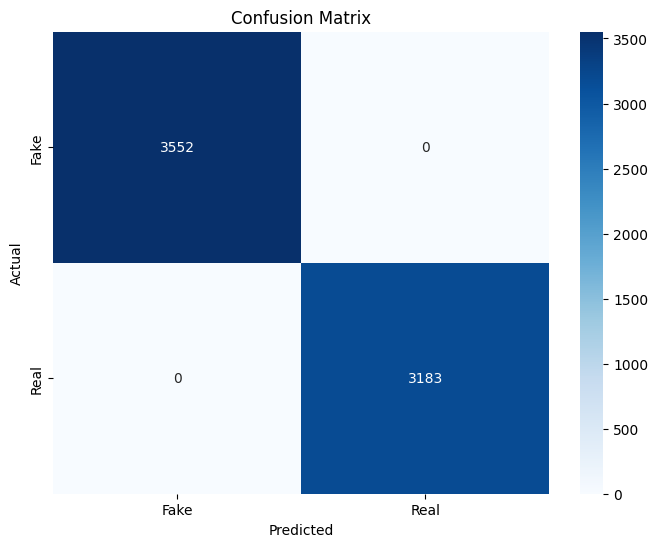

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predictions = trainer.predict(tokenized_test)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
def predict_news(text):
    inputs = tokenizer(text, padding="max_length", truncation=True, max_length=256, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        prediction = torch.argmax(logits, dim=-1).item()

    return "Real News" if prediction == 1 else "Fake News"

custom_text = "Washington (Reuters) - The government announced a new policy regarding international trade today."
result = predict_news(custom_text)
print(f"Prediction: {result}")

Prediction: Real News


In [ ]:
user_input = "Argentina has won 2022 world cup"
print(predict_news(user_input))

Fake News
